Part A: Regression (Medical Cost Prediction)

SECTION 1 - Data Understanding

(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


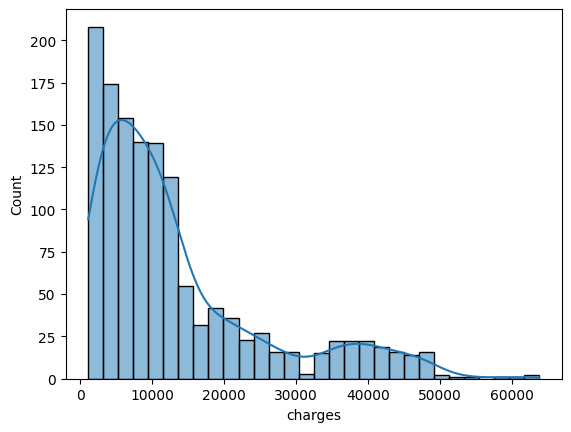

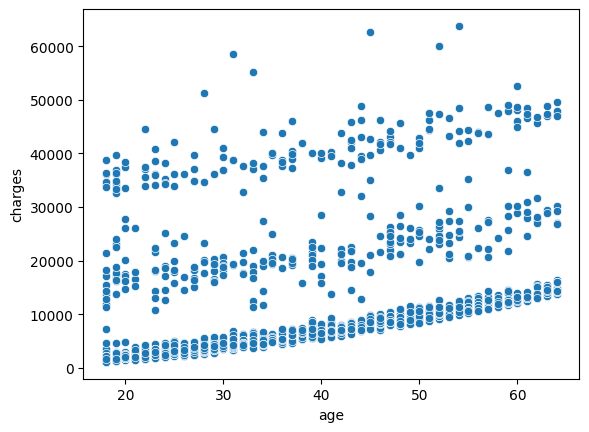

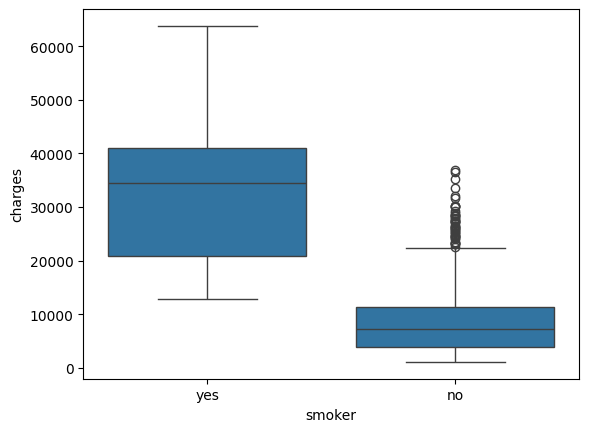

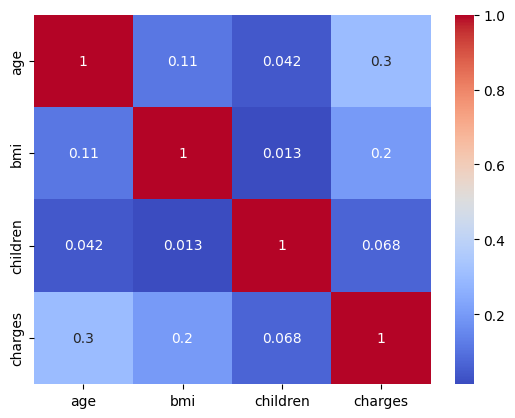

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.head())

print(df.isnull().sum())
print(df.duplicated().sum())

sns.histplot(df['charges'], kde=True)
plt.show()

sns.scatterplot(x='age', y='charges', data=df)
plt.show()

sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

Observations:
1. Charges are right-skewed.

 2. Smokers pay significantly more

 3. Age correlates positively with charges

SECTION 2 - Preprocessing

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


SECTION 3 - Model Building


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 13346.089736364485
Coefficients: [ 3.61497541e+03  2.03622812e+03  5.16890247e+02 -9.29310107e+00
  9.55848141e+03 -1.58140981e+02 -2.90157047e+02 -3.49110678e+02]


SECTION 4 - Evaluation

MAE: 4181.194473753651
MSE: 33596915.851361476
RMSE: 5796.284659276274
R2 Score: 0.7835929767120722


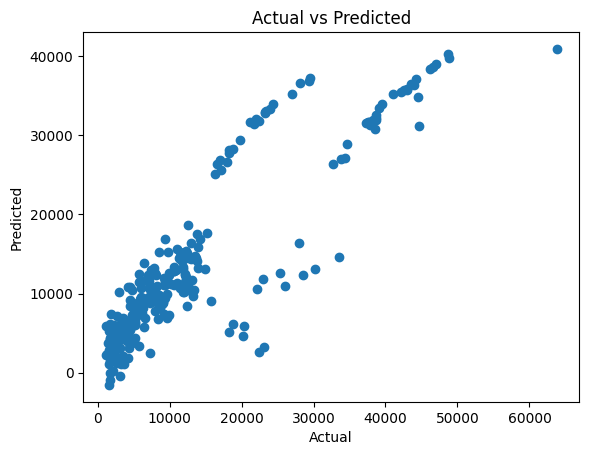

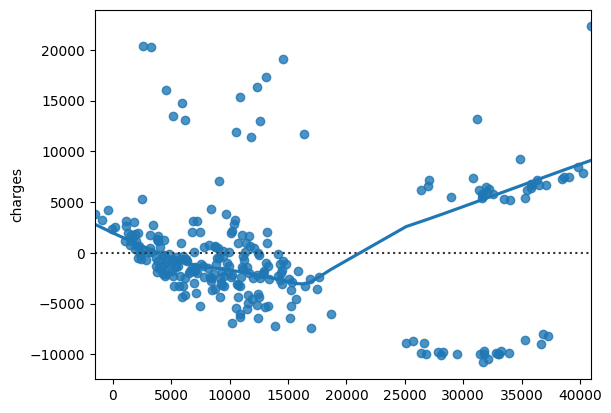

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True)
plt.show()

PART B - CLASSIFICATION

SECTION 1 - Data Understanding

(4803, 20)
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: obj

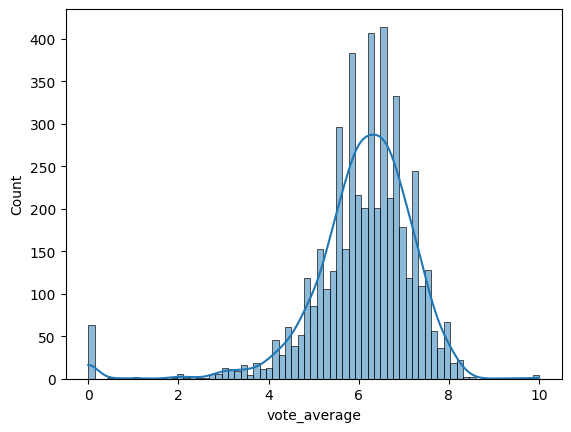

In [10]:
df_movies = pd.read_csv("tmdb_5000_movies.csv")

print(df_movies.shape)
print(df_movies.columns)
print(df_movies.dtypes)

print(df_movies.isnull().sum())

df_movies['Hit'] = (df_movies['vote_average'] >= 7).astype(int)
print(df_movies['Hit'].value_counts())

sns.histplot(df_movies['vote_average'], kde=True)
plt.show()

Observations:
1. Ratings cluster around 5–7

2. Dataset may be imbalanced

3. Hit threshold (>=7) separates classes

SECTION 2 - Preprocessing

In [22]:
# Reload df_movies to ensure all original columns are present
df_movies = pd.read_csv("tmdb_5000_movies.csv")
# Re-add the 'Hit' column, as it's part of the data understanding setup
df_movies['Hit'] = (df_movies['vote_average'] >= 7).astype(int)

df_movies = df_movies.drop(['id','title', 'homepage', 'tagline'], axis=1)
df_movies = df_movies.dropna() # Drop rows with any remaining NaNs
df_movies_encoded = pd.get_dummies(df_movies, drop_first=True)

X = df_movies_encoded.drop('Hit', axis=1)
y = df_movies_encoded['Hit'].values.astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
s_scaler = StandardScaler()
X_train_scaled = s_scaler.fit_transform(X_train)
X_test_scaled = s_scaler.transform(X_test)

SECTION 3 - Model Building

In [23]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

print("Coefficients:", clf.coef_)

Coefficients: [[-0.05836991  0.19335398  0.11325787 ...  0.00897844 -0.01041278
   0.02486636]]


SECTION 4 - Evaluation

Accuracy: 0.80625
Precision: 1.0
Recall: 0.05102040816326531
F1 Score: 0.0970873786407767


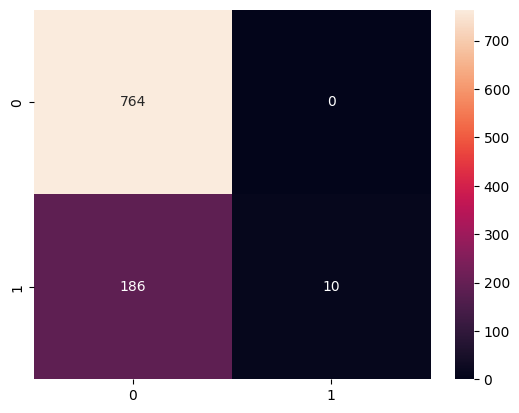

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

1. Accuracy alone is not enough if dataset is imbalanced.

2. Precision/Recall/F1 give better insights.

SECTION 5 - Business Interpretation

1. Which variable impacts charges the most?

Smoking status has the strongest impact on medical charges — smokers consistently pay far higher premiums.

2. How much more do smokers pay?

On average, smokers pay several thousand dollars more annually compared to non-smokers, making it the most costly factor.

3. Is BMI statistically impactful?

Yes, BMI does influence charges, but its effect is weaker than smoking and age. It’s significant but not the top driver.

4. Can this model be used in production? Why or why not?

Not directly — while Linear Regression is interpretable, the dataset shows non-linear patterns. More advanced models (like Random Forest or Gradient Boosting) would likely perform better in production.